# Unidad 2: Aprendizaje Automático
## 🎚️ Sensibilidad, Especificidad y Umbral de Decisión
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

---
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/ml/18_Sensitivity_Specificity.ipynb)


## 🎯 ¿Qué vamos a aprender?

En el notebook anterior calculamos métricas con el **umbral por defecto (0.5)**. Pero ese umbral no siempre es el más adecuado. En este notebook aprenderemos a **ajustar el umbral de decisión** y a entender cómo eso afecta la Sensibilidad y la Especificidad.

Al finalizar, vas a poder:
- ✅ Entender la diferencia entre **Sensibilidad** y **Especificidad**
- ✅ Usar `predict_proba()` para obtener **probabilidades** en lugar de clases directamente
- ✅ Aplicar un **umbral personalizado** (≠ 0.5) para ajustar la predicción
- ✅ Analizar el **trade-off entre Precision y Recall** al mover el umbral
- ✅ Saber cuándo conviene usar cada umbral según el contexto

---

## 🧠 Marco Teórico

### 🔬 Sensibilidad y Especificidad

Estas métricas provienen del ámbito clínico y estadístico:

| Métrica | Fórmula | Alias en ML | ¿Qué mide? |
|---------|---------|-------------|------------|
| **Sensibilidad** | $\frac{TP}{TP+FN}$ | Recall / TPR | ¿Qué fracción de positivos reales detecté? |
| **Especificidad** | $\frac{TN}{TN+FP}$ | TNR | ¿Qué fracción de negativos reales identificé correctamente? |

$$\text{Sensibilidad} = \text{Recall} = \frac{TP}{TP + FN}$$

$$\text{Especificidad} = \frac{TN}{TN + FP} = \text{Recall de la clase negativa}$$

### 🎚️ El Umbral de Decisión

Un clasificador como `LogisticRegression` no predice directamente las clases: internamente **calcula una probabilidad** para cada clase. La decisión final depende de un **umbral** $\theta$:

$$\hat{y} = \begin{cases} 1 & \text{si } P(y=1|x) \geq \theta \\ 0 & \text{si } P(y=1|x) < \theta \end{cases}$$

Por defecto, $\theta = 0.5$. Pero podemos modificarlo:

```
Umbral más bajo (ej: 0.3):
  → Más predicciones positivas
  → ↑ Recall (Sensibilidad)  pero ↓ Precision (más FP)

Umbral más alto (ej: 0.75):
  → Menos predicciones positivas
  → ↑ Precision (menos FP) pero ↓ Recall (más FN)
```

### 🏥 Contexto de aplicación

| Escenario | Prioridad | Umbral sugerido |
|-----------|-----------|----------------|
| Diagnóstico de enfermedad grave | ↑ Recall (no perder enfermos) | < 0.5 |
| Filtrado de spam | ↑ Precision (no borrar correos legítimos) | > 0.5 |
| Sistema antifraude bancario | ↑ Recall (no perder fraudes) | < 0.5 |
| Publicidad personalizada | Balance (F1) | ≈ 0.5 |

> 📌 **Referencias:**
> - Scikit-learn: [precision_recall_fscore_support](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html)
> - Scikit-learn: [predict_proba](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict_proba)
> - Hajian-Tilaki, K. (2013). [Receiver Operating Characteristic (ROC) Curve Analysis for Medical Diagnostic Test Evaluation](https://doi.org/10.5812/cpj.3484). *Caspian J. Intern. Med.*, 4(2), 627–635.

---

## 📦 Paso 1: Importar las Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import precision_recall_fscore_support

# Sensitivity = Recall (son sinónimos)
sensitivity_score = recall_score

def specificity_score(y_true, y_pred):
    """Especificidad = Recall de la clase negativa (TNR)."""
    _, r, _, _ = precision_recall_fscore_support(y_true, y_pred)
    return r[0]   # r[0] = recall del label 0 (clase negativa)

print('✅ Librerías importadas correctamente!')
print('\n💡 sensitivity_score = recall_score (son exactamente equivalentes)')

✅ Librerías importadas correctamente!

💡 sensitivity_score = recall_score (son exactamente equivalentes)


## 📂 Paso 2: Cargar Datos y Entrenar el Modelo

In [4]:
# 📥 Cargar dataset
df = pd.read_csv('https://raw.githubusercontent.com/CristianPacifico/ia-ls-fcad-uner/main/data/ml/titanic.csv')
df['male'] = df['Sex'] == 'male'

X = df[['Pclass', 'male', 'Age', 'Siblings/Spouses', 'Parents/Children', 'Fare']].values
y = df['Survived'].values

# ✂️ División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 🤖 Entrenar Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print(f'✅ Modelo entrenado — Accuracy test: {model.score(X_test, y_test):.4f}')

✅ Modelo entrenado — Accuracy test: 0.7658


## 🎲 Paso 3: Probabilidades vs Clases

Con `predict_proba()` obtenemos la **distribución de probabilidad** para cada pasajero, antes de aplicar el umbral.

In [6]:
# 🎲 Obtener probabilidades
y_prob = model.predict_proba(X_test)   # Shape: (n, 2) → [P(no), P(sí)]
y_preddef = model.predict(X_test)       # Predicción con umbral por defecto 0.5

# Mostrar las primeras 15 muestras
print('🎲 Probabilidades → Predicción (umbral 0.50):')
print(f'{"P(No sobrv)":>14} {"P(Sobrv)":>10} {"Pred (0.5)":>12} {"Real":>6}')
print('-' * 47)
for i in range(15):
    p_no = y_prob[i][0]
    p_si = y_prob[i][1]
    pred = y_preddef[i]
    real = y_test[i]
    ok = '✅' if pred == real else '❌'
    print(f'{p_no:>14.4f} {p_si:>10.4f} {pred:>12} {real:>6} {ok}')

🎲 Probabilidades → Predicción (umbral 0.50):
   P(No sobrv)   P(Sobrv)   Pred (0.5)   Real
-----------------------------------------------
        0.6547     0.3453            0      1 ❌
        0.8021     0.1979            0      0 ✅
        0.9783     0.0217            0      0 ✅
        0.7290     0.2710            0      1 ❌
        0.9017     0.0983            0      0 ✅
        0.3218     0.6782            1      1 ✅
        0.9007     0.0993            0      0 ✅
        0.8714     0.1286            0      0 ✅
        0.3624     0.6376            1      1 ✅
        0.4125     0.5875            1      1 ✅
        0.5308     0.4692            0      1 ❌
        0.3108     0.6892            1      1 ✅
        0.4094     0.5906            1      1 ✅
        0.9544     0.0456            0      0 ✅
        0.5018     0.4982            0      1 ❌


## 🎚️ Paso 4: Aplicar un Umbral Personalizado (0.75)

Elevamos el umbral a **0.75**: el modelo sólo predice "sobrevivió" si está **muy seguro** (P ≥ 75%). Esto aumentará la Precision pero reducirá el Recall.

In [7]:
# 🎚️ Umbral personalizado: 0.75
UMBRAL = 0.75
y_pred75 = (y_prob[:, 1] >= UMBRAL).astype(int)

print(f'🎚️  Umbral aplicado: {UMBRAL}')
print(f'\n📊 Comparación de predicciones:')
print(f'  Predichos positivos (umbral 0.50): {y_preddef.sum()}')
print(f'  Predichos positivos (umbral 0.75): {y_pred75.sum()}')
print(f'\n🎲 Primeras 15 muestras — umbral 0.75:')
print(f'{"P(Sobrv)":>10} {"Pred (0.5)":>12} {"Pred (0.75)":>13} {"Real":>6}')
print('-' * 45)
for i in range(15):
    p_si = y_prob[i][1]
    cambio = ' ← cambió!' if y_preddef[i] != y_pred75[i] else ''
    print(f'{p_si:>10.4f} {y_preddef[i]:>12} {y_pred75[i]:>13} {y_test[i]:>6}{cambio}')

🎚️  Umbral aplicado: 0.75

📊 Comparación de predicciones:
  Predichos positivos (umbral 0.50): 66
  Predichos positivos (umbral 0.75): 35

🎲 Primeras 15 muestras — umbral 0.75:
  P(Sobrv)   Pred (0.5)   Pred (0.75)   Real
---------------------------------------------
    0.3453            0             0      1
    0.1979            0             0      0
    0.0217            0             0      0
    0.2710            0             0      1
    0.0983            0             0      0
    0.6782            1             0      1 ← cambió!
    0.0993            0             0      0
    0.1286            0             0      0
    0.6376            1             0      1 ← cambió!
    0.5875            1             0      1 ← cambió!
    0.4692            0             0      1
    0.6892            1             0      1 ← cambió!
    0.5906            1             0      1 ← cambió!
    0.0456            0             0      0
    0.4982            0             0      1


## 📊 Paso 5: Comparar Métricas — Umbral 0.50 vs 0.75

In [9]:
def comparar_umbrales(y_true, y_pred_05, y_pred_75):
    metricas = ['Precision', 'Sensitivity/Recall', 'Specificity']
    funcs_05 = [
        precision_score(y_true, y_pred_05),
        sensitivity_score(y_true, y_pred_05),
        specificity_score(y_true, y_pred_05),
    ]
    funcs_75 = [
        precision_score(y_true, y_pred_75),
        sensitivity_score(y_true, y_pred_75),
        specificity_score(y_true, y_pred_75),
    ]
    return metricas, funcs_05, funcs_75

metricas, vals_05, vals_75 = comparar_umbrales(y_test, y_preddef, y_pred75)

print('=' * 62)
print('       📊 IMPACTO DEL UMBRAL EN LAS MÉTRICAS')
print('=' * 62)
print(f'{"Métrica":<22} {"Umbral 0.50":>14} {"Umbral 0.75":>14} {"Δ":>8}')
print('-' * 62)
for m, v05, v75 in zip(metricas, vals_05, vals_75):
    diff  = v75 - v05
    emoji = '⬆️' if diff > 0.001 else ('⬇️' if diff < -0.001 else '➡️')
    print(f'{m:<22} {v05:>14.5f} {v75:>14.5f} {diff:>+7.5f} {emoji}')
print('=' * 62)
print('\n💡 Conclusion: Subir el umbral mejora Precision y Specificity')
print('               pero reduce Sensitivity/Recall.')

       📊 IMPACTO DEL UMBRAL EN LAS MÉTRICAS
Métrica                   Umbral 0.50    Umbral 0.75        Δ
--------------------------------------------------------------
Precision                     0.72727        0.88571 +0.15844 ⬆️
Sensitivity/Recall            0.58537        0.37805 -0.20732 ⬇️
Specificity                   0.87143        0.97143 +0.10000 ⬆️

💡 Conclusion: Subir el umbral mejora Precision y Specificity
               pero reduce Sensitivity/Recall.


## 📈 Paso 6: Curva Precision-Recall vs Umbral

Visualizamos cómo cambian **Precision, Recall y Specificity** al variar el umbral entre 0.1 y 0.95.

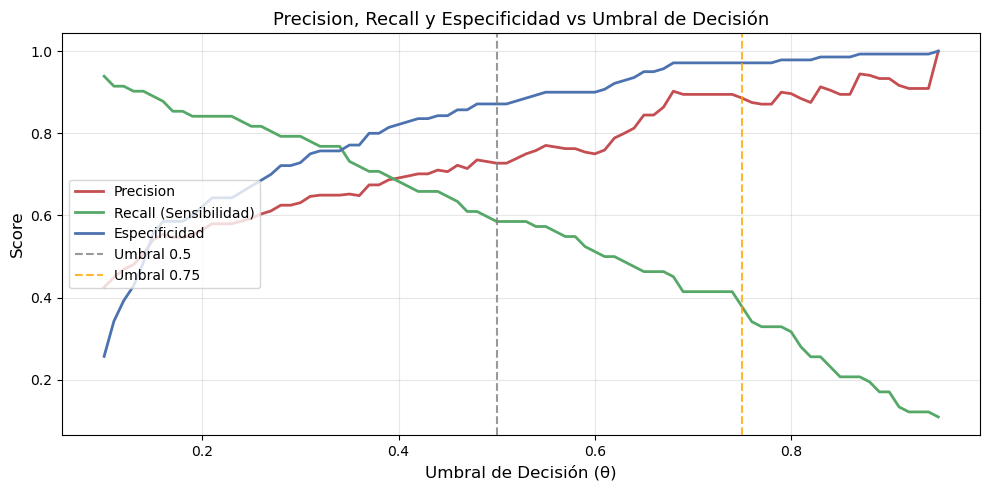


💡 Al subir el umbral:
   → Precision y Especificidad suben (menos FP)
   → Recall/Sensibilidad baja (más FN)


In [10]:
# 📈 Barrer umbrales de 0.10 a 0.95
umbrales    = np.arange(0.10, 0.96, 0.01)
precisions  = []
recalls     = []
specificities = []

for t in umbrales:
    y_t = (y_prob[:, 1] >= t).astype(int)
    if y_t.sum() == 0:         # evitar división por cero en precision
        precisions.append(np.nan)
    else:
        precisions.append(precision_score(y_test, y_t, zero_division=0))
    recalls.append(recall_score(y_test, y_t, zero_division=0))
    specificities.append(specificity_score(y_test, y_t))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(umbrales, precisions,    label='Precision',            color='#C44E52', linewidth=2)
ax.plot(umbrales, recalls,       label='Recall (Sensibilidad)', color='#55A868', linewidth=2)
ax.plot(umbrales, specificities, label='Especificidad',         color='#4C72B0', linewidth=2)

# Marcar los umbrales 0.50 y 0.75
for t, c in [(0.50, 'gray'), (0.75, 'orange')]:
    ax.axvline(x=t, color=c, linestyle='--', linewidth=1.5, alpha=0.8, label=f'Umbral {t}')

ax.set_xlabel('Umbral de Decisión (θ)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall y Especificidad vs Umbral de Decisión', fontsize=13)
ax.legend(fontsize=10, loc='center left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\n💡 Al subir el umbral:')
print('   → Precision y Especificidad suben (menos FP)')
print('   → Recall/Sensibilidad baja (más FN)')

## 🏁 Conclusiones

En este notebook aprendimos:

1. 🎲 `predict_proba()` muestra la **distribución de probabilidad** interna del modelo antes de aplicar el umbral.
2. 🎚️ El **umbral de decisión** $\theta$ controla el trade-off entre Precision y Recall:
   - Umbral ↑ → más precisos pero más FN (perdemos casos positivos)
   - Umbral ↓ → más sensibles pero más FP (clasificamos como positivo a quien no lo es)
3. 🔬 **Sensibilidad** = Recall: fracción de positivos reales detectados.
4. 🔬 **Especificidad** = Recall de la clase negativa: fracción de negativos reales identificados.
5. 🏥 La elección del umbral no es técnica sino **contextual**: depende del costo relativo de los errores.

### ➡️ Próximo notebook: Curva ROC y AUC

---

## 📚 Referencias

- Scikit-learn: [precision_recall_fscore_support](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html)
- Hajian-Tilaki, K. (2013). [Receiver Operating Characteristic (ROC) Curve Analysis for Medical Diagnostic Test Evaluation](https://doi.org/10.5812/cpj.3484). *Caspian J. Intern. Med.*, 4(2), 627–635.
- Davis, J., & Goadrich, M. (2006). [The relationship between Precision-Recall and ROC curves](https://dl.acm.org/doi/10.1145/1143844.1143874). *ICML*.